# POSUMOWANIE i WIZUALIZACJE
W notebooku zostały umieszczone otrzymane vizualizacje na podstawie wytrenowanego modelu pointnet znajdującego się w `src/models/pointnet` oraz bardziej szczegółowy opis.


### 1. Porównanie metod- przykład pozytywny.

W projekcie do analizy wyjaśnialności wykorzystano dwie popularne metody post-hoc: LIME oraz SHAP. Obie metody są niezależne od architektury modelu, co oznacza, że mogą zostać zastosowane do dowolnego klasyfikatora bez ingerencji w proces treningu lub strukturę sieci.

Metoda **LIME** działa poprzez generowanie wielu lokalnych perturbacji danych wejściowych i obserwację zmian w predykcji modelu. Na tej podstawie budowany jest uproszczony model lokalny, który aproksymuje zachowanie oryginalnego modelu w najbliższym otoczeniu analizowanego przykładu. Dzięki temu możliwe jest określenie, które fragmenty wejścia miały największy wpływ na konkretną predykcję.

Metoda **SHAP** opiera się na wartościach Shapley’a wywodzących się z teorii gier. Dla każdego elementu wejścia obliczany jest jego wkład do końcowej decyzji modelu poprzez analizę wielu kombinacji obecności i nieobecności tego elementu. Pozwala to uzyskać bardziej globalnie spójną interpretację wpływu poszczególnych fragmentów danych.

Na poniższym przykładzie przedstawiono porównanie obu metod na obiekcie **samolot**, który został poprawnie sklasyfikowany przez model PointNet.

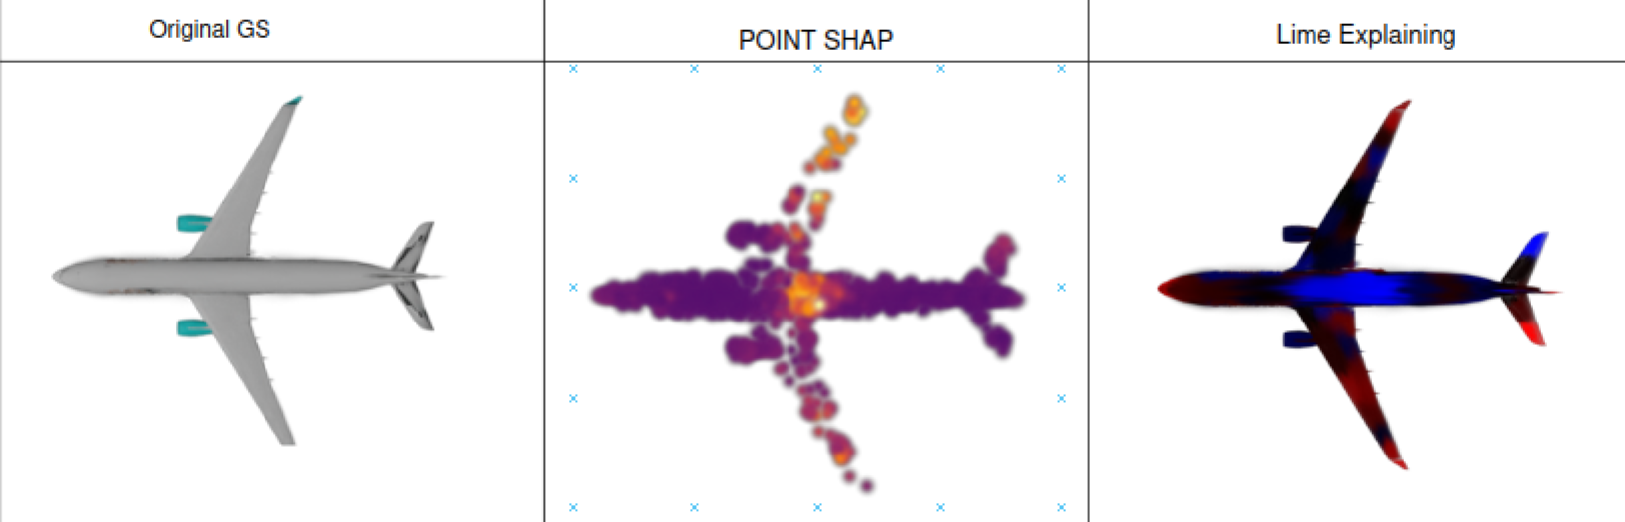

Na ilustracji widzimy kolejno:

* **obiekt oryginalny** — wejściową reprezentację chmury punktów,
* **PointSHAP** — heatmapę istotności punktów wygenerowaną przez SHAP,
* **PointLIME** — heatmapę istotności punktów wygenerowaną przez LIME.

Interpretacja obu metod jest podobna: im cieplejszy kolor (bardziej czerwony lub jaśniejszy), tym większy wpływ danego fragmentu obiektu na końcową decyzję modelu.

Na przykładzie samolotu widać, że obie metody identyfikują kluczowe, charakterystyczne części obiektu- przede wszystkim końcówki skrzydeł. Jednocześnie różnią się sposobem rozkładania istotności: SHAP tworzy bardziej ciągłe i skupione obszary ważności, podczas gdy LIME prezentuje bardziej lokalne i kontrastowe przypisanie wpływu, często silniej rozdzielając fragmenty wspierające i osłabiające predykcję. Ciekawą uwagą jest fakt jak sam środek kadłubu był traktowany przez obie metody, gdzie dla SHAPA był to istotny fragment, podczas gdy LIME oznaczył go kolorem niebieskim czyli osłabiającym pewność modelu.

To porównanie pokazuje, że mimo podobnego celu interpretacyjnego obie metody mogą prowadzić do nieco innych perspektyw interpretacji tej samej decyzji modelu, co jest istotne przy analizie zachowania systemów AI.


Warto zwrócić uwagę również na drugi przykład poprawnie sklasyfikowanego obiektu — jelenia. W tym przypadku różnice pomiędzy metodami są jeszcze bardziej widoczne.


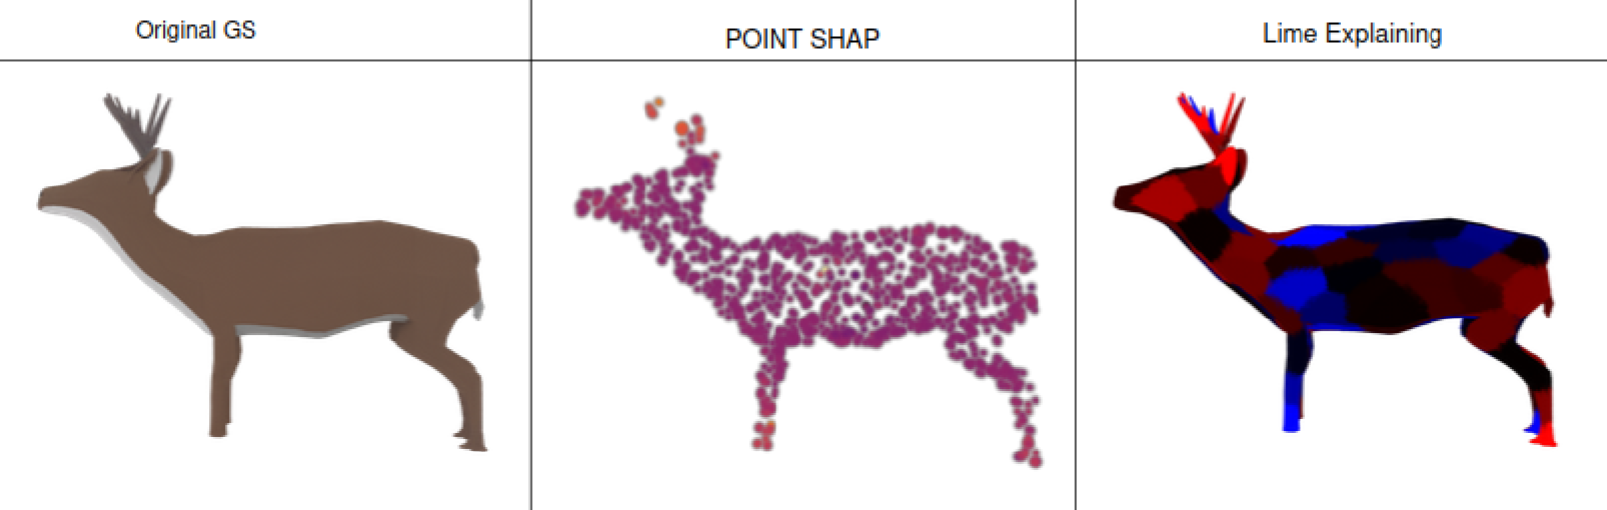

Metoda SHAP wskazuje bardzo wyraźnie jeden dominujący obszar istotności- poroże, które stanowi najbardziej charakterystyczny element obiektu i z perspektywy modelu miało największy wpływ na poprawną klasyfikację. Pozostałe części ciała otrzymują znacznie niższą istotność.

Z kolei LIME oprócz poroża zaznacza również inne fragmenty ciała, takie jak głowa, tułów oraz nogi, rozkładając uwagę modelu na większą liczbę obszarów.

Ten przykład dobrze pokazuje różnicę interpretacyjną między obiema metodami: SHAP częściej identyfikuje pojedyncze, najbardziej charakterystyczne cechy obiektu, podczas gdy LIME ma tendencję do bardziej rozproszonego przypisywania istotności. W praktyce może to prowadzić do różnych sposobów interpretacji tej samej decyzji modelu.

# 2. Klasyfikacje
Poniżej przedstawiono przykładowe wizualizacje wyjaśnialności dla kilku obiektów, które zostały poprawnie sklasyfikowane przez model. Zestawienia te pozwalają porównać sposób, w jaki metody LIME oraz SHAP identyfikują najważniejsze fragmenty obiektów odpowiedzialne za końcową predykcję modelu.

1. Klasa drzewo:
Poniższy przykład został poprawnie zaklasyfikowany. Widać jednak że metody zwracają uwagę na zupełnie inne rejony w tym przypadku. Podczas gdy czubek choinki był uznany za kluczowy dla LIME, SHAP wskazał go jako obszar o małym znaczeniu.


<video controls width="100%">
  <source src="../wyniki/gifs/traj_tree_001_comparison.mp4" type="video/mp4">
</video>


2. Klasa Mikrofon:

<img src="../wyniki/gifs/traj_microphone_001.gif" width="100%" />

3. Klasa słuchawki
<img src="../wyniki/gifs/traj_earphone_011.gif" width="100%" />



Poniżej przedstawiono przykład wyjaśnialności dla obiektu, który został błędnie sklasyfikowany przez model. Tego typu przypadki są szczególnie istotne, ponieważ pozwalają przeanalizować, na jakie fragmenty obiektu model zwracał uwagę podczas podejmowania niepoprawnej decyzji oraz które cechy mogły prowadzić do błędnej interpretacji danych wejściowych przez klasyfikator. W obecnej analizie najciekawszym okazał się poniższy przypadek gdzie obiekt klasy kapelusza został zakwalifikowany jako miska. Oba obiekty są dość podobne kształtem, przez co model (a i przez to metody wyjaśniajace), nie były w stanie znaleźć żadnego charakterystycznego obszaru, który mógłby pomóc w predykcji. Widzimy też dlatego praktycznie "losowe" obszary, które wpłynęły na pewność modelu. 

<video controls width="100%">
  <source src="../wyniki/gifs/traj_hat_026_comparison.mp4" type="video/mp4">
</video>





# 3. ANKIETA Z WYNIKAMI

Przeprowadzono krótką ankietę, w której uczestnicy oceniali wizualizacje wyjaśnialności wygenerowane przez obie metody na różnych przykładach obiektów 3D. Każdy respondent analizował około 10 przykładów wizualizacji i przyznawał ocenę w skali od 0 do 3, gdzie 0 oznaczało brak użyteczności wyjaśnienia, a 3 wysoką pomoc w zrozumieniu decyzji modelu i zwiększeniu pewności co do poprawności predykcji. Zebrane odpowiedzi pozwoliły porównać użyteczność interpretacyjną obu metod, a ich podsumowanie przedstawiono w tabeli poniżej.

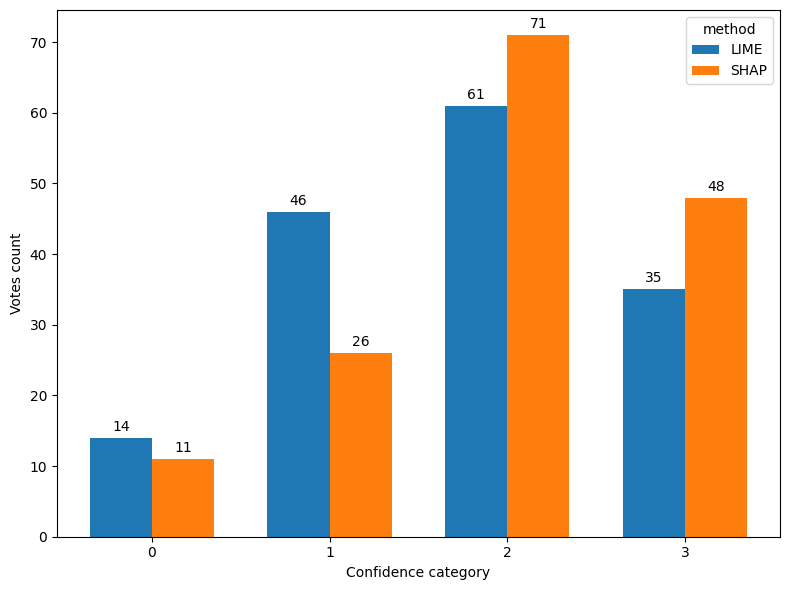

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../wyniki/user_study_results.csv")

categories = df["confidence_category"]
lime = df["LIME"]
shap = df["SHAP"]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(x - width/2, lime, width, label="LIME")
plt.bar(x + width/2, shap, width, label="SHAP")

plt.xlabel("Confidence category")
plt.ylabel("Votes count")
plt.xticks(x, categories)
plt.legend(title="method")

for i, v in enumerate(lime):
    plt.text(x[i] - width/2, v + 1, str(v), ha="center")

for i, v in enumerate(shap):
    plt.text(x[i] + width/2, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

# 3.Podsumowanie projektu

Projekt pokazał, że metody wyjaśnialności takie jak LIME oraz SHAP mogą zostać skutecznie zaadaptowane do analizy modeli klasyfikujących obiekty 3D reprezentowane jako chmury punktów. Przeprowadzone eksperymenty potwierdziły, że mimo podobnego celu interpretacyjnego obie metody mogą wskazywać różne obszary istotności, co pokazuje, że interpretacja decyzji modelu nie zawsze jest jednoznaczna i zależy od przyjętej techniki explainability.

Analiza wykazała również, że prostsze architektury, takie jak PointNet, mogą stanowić bardzo dobry kompromis pomiędzy skutecznością klasyfikacji, szybkością działania oraz możliwością praktycznego zastosowania metod wyjaśnialności. W kontekście systemów produkcyjnych jest to szczególnie istotne, ponieważ explainability wiąże się z dodatkowymi kosztami obliczeniowymi, które muszą być uwzględniane już na etapie projektowania rozwiązania.

W rzeczywistych systemach wykorzystujących sztuczną inteligencję — szczególnie w obszarach takich jak robotyka, pojazdy autonomiczne, medycyna czy systemy bezpieczeństwa — możliwość wyjaśnienia decyzji modelu staje się coraz ważniejsza, a często wręcz wymagana przez regulacje prawne oraz standardy etyczne. Transparentność modeli pozwala budować większe zaufanie użytkowników, ułatwia audytowanie decyzji oraz wspiera identyfikację błędów lub niepożądanych wzorców działania modelu.

Projekt stanowi praktyczny przykład tego, że explainability dla danych 3D jest możliwe i użyteczne, ale nadal pozostaje obszarem wymagającym dalszych badań — zarówno pod względem jakości wyjaśnień, jak i ich efektywności obliczeniowej. W przyszłości naturalnym rozwinięciem będzie rozszerzenie analizy na większą liczbę modeli oraz zastosowanie metod natywnie projektowanych dla danych przestrzennych.
